In [31]:
import pandas as pd
import xgboost as xgb

# Load the data
test_df = pd.read_json('data/test.json')
train_df = pd.read_json('data/train.json')


In [43]:
numbers = []
for i in range(len(train_df)):
    numbers.append(train_df['atoms'].iloc[i])

#len(numbers[0].get('numbers'))

numbers_set = []
for i in range(len(numbers)):
    numbers_set.append(numbers[i].get('numbers'))

    



8000


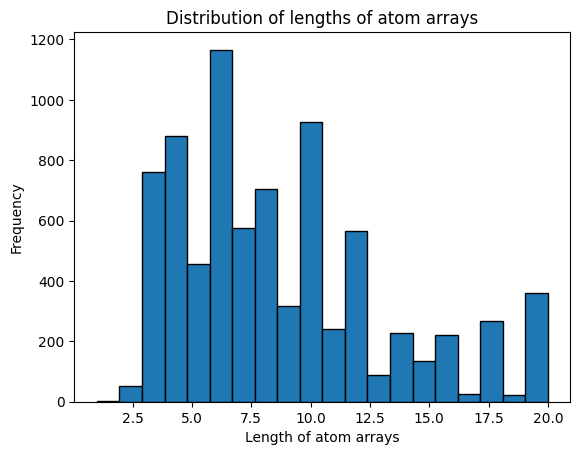

In [45]:
import matplotlib.pyplot as plt

# Calculate the lengths of the arrays
lengths = [len(arr) for arr in numbers_set]

# Plot the distribution of lengths
plt.hist(lengths, bins=20, edgecolor='black')
plt.xlabel('Length of atom arrays')
plt.ylabel('Frequency')
plt.title('Distribution of lengths of atom arrays')
plt.show()

In [21]:

print(train_df[train_df['id'] == 1634])

     id        formula                                              atoms  \
2  1634  Cd4K2Cl6O6Te2  {'numbers': [48, 48, 48, 48, 19, 19, 52, 52, 8...   

      hform  
2 -1.109751  


In [13]:
import pandas as pd
import xgboost as xgb

# Load the data
test_df = pd.read_json('data/test.json')
train_df = pd.read_json('data/train.json')

def expand_atoms_dict(atoms_dict):
    """
    Given a dict like:
    
    {
        'numbers': [...],
        'positions': [[x,y,z], ...],
        'cell': [[x,y,z], ...],
        'pbc': [bool,bool,bool],
        ...
    }
    
    returns a flattened dict of key-value pairs like:
    
    {
        'atom_0': <number>,
        'atom_1': <number>,
        ...
        'atom_0_x': <float>,
        'atom_0_y': <float>,
        'atom_0_z': <float>,
        ...
        'cell_0_x': <float>,
        ...
        'pbc_x': <bool>,
        'pbc_y': <bool>,
        'pbc_z': <bool>,
        ...
    }
    """
    if not isinstance(atoms_dict, dict):
        # Handle null or non-dict values gracefully
        return {}
    
    row = {}
    
    # ---------------------
    # 1) numbers -> atom_0, atom_1, ...
    # ---------------------
    numbers = atoms_dict.get('numbers', [])
    for i, num in enumerate(numbers):
        row[f'atom_{i}'] = num
        
    # ---------------------
    # 2) positions -> atom_0_x, atom_0_y, atom_0_z, ...
    # ---------------------
    positions = atoms_dict.get('positions', [])
    for i, coords in enumerate(positions):
        # Ensure each coords has at least length 3 to avoid index errors
        x, y, z = (coords + [None, None, None])[:3]
        row[f'atom_{i}_x'] = x
        row[f'atom_{i}_y'] = y
        row[f'atom_{i}_z'] = z
        
    # ---------------------
    # 3) cell -> cell_0_x, cell_0_y, cell_0_z, ...
    # ---------------------
    cell = atoms_dict.get('cell', [])
    cell_axes = ['a', 'b', 'c']
    for i, ccoords in enumerate(cell):
        axis = cell_axes[i] if i < len(cell_axes) else str(i)
        x, y, z = (ccoords + [None, None, None])[:3]
        row[f'cell_{axis}_x'] = x
        row[f'cell_{axis}_y'] = y
        row[f'cell_{axis}_z'] = z
        
    # ---------------------
    # 4) pbc -> pbc_x, pbc_y, pbc_z, ...
    #    (Assuming pbc has up to 3 elements)
    # ---------------------
    pbc = atoms_dict.get('pbc', [])
    pbc_axes = ['x', 'y', 'z']
    for i, flag in enumerate(pbc):
        axis = pbc_axes[i] if i < len(pbc_axes) else str(i)
        row[f'pbc_{axis}'] = flag
        
    return row

df_expanded = train_df['atoms'].apply(lambda d: pd.Series(expand_atoms_dict(d)))
df_train_result = train_df.drop(columns=['atoms']).join(df_expanded)

In [ ]:
print(train_df['atoms'][0])
expand_atoms_dict(train_df['atoms'][0])

In [30]:
print(df_train_result["hform"].std(),
      df_train_result["hform"].mean(), 
      df_train_result["hform"].max(),
        df_train_result["hform"].min())

0.6727046678897787 -0.6228658434441124 1.7677214251 -4.0167007465


In [25]:
df_train_result.shape

(8000, 95)

## Transforms: 

Numbers -> atom(sub0), ..., atom(subN) 
Postions -> x,y,z coordinates in unit cell 

In [1]:
from ase import Atoms 
import json

with open('data/train.json', 'r') as file:
    data_dict = json.load(file)

In [ ]:
first_entry = {key: value['0'] for key, value in data_dict.items()}
-- print(first_entry)

-- atom_object = Atoms(first_entry['formula'], numbers=first_entry['atoms']['numbers'])
-- print(first_entry['formula'])
-- print(first_entry['atoms']['numbers'])


In [3]:
first_entry = {key: value['0'] for key, value in data_dict.items()}
print(first_entry)
print(first_entry['formula'])

{'id': 5154, 'formula': 'Zr2BO2', 'atoms': {'numbers': [40, 40, 5, 8, 8], 'positions': [[1.6878604657, 0.892285133, 8.1345931364], [0.0392147604, 1.8476649126, 11.3052038961], [1.6910961648, 2.8023560774, 9.7199016851], [1.6914938266, 0.8928251492, 12.2138197727], [0.0352527402, 1.8476962382, 7.2259733944]], 'cell': [[3.3066555367, 6.350146766e-19, 0.0], [-1.6514970437, 2.8647038858, 0.0], [0.0, 0.0, 19.4398020174]], 'pbc': [True, True, False]}, 'hform': -2.0378774036}


In [50]:
import json

with open('example.json', 'w') as file:
    json.dump(data_dict, file, indent=4)

In [14]:
def convert_arrays_to_tuples(data):
    """
    Convert the nested lists in `numbers`, `positions`, `cell`, and `pbc`
    inside data['atoms'] into tuples (including nested lists).
    """

    # Convert numbers from list to tuple
    data["atoms"]["numbers"] = tuple(data["atoms"]["numbers"])

    # Convert positions from list of lists to tuple of tuples
    data["atoms"]["positions"] = tuple(tuple(pos) for pos in data["atoms"]["positions"])

    # Convert cell from list of lists to tuple of tuples
    data["atoms"]["cell"] = tuple(tuple(c) for c in data["atoms"]["cell"])

    # Convert pbc from list to tuple
    data["atoms"]["pbc"] = tuple(data["atoms"]["pbc"])

    return data



converted_dict = convert_arrays_to_tuples(first_entry)
print(converted_dict)



{'id': 5154, 'formula': 'Zr2BO2', 'atoms': {'numbers': (40, 40, 5, 8, 8), 'positions': ((1.6878604657, 0.892285133, 8.1345931364), (0.0392147604, 1.8476649126, 11.3052038961), (1.6910961648, 2.8023560774, 9.7199016851), (1.6914938266, 0.8928251492, 12.2138197727), (0.0352527402, 1.8476962382, 7.2259733944)), 'cell': ((3.3066555367, 6.350146766e-19, 0.0), (-1.6514970437, 2.8647038858, 0.0), (0.0, 0.0, 19.4398020174)), 'pbc': (True, True, False)}, 'hform': -2.0378774036}


In [42]:
import ase.data as data
import ase.calculators as calcs
atom_object = Atoms(numbers=converted_dict['atoms']['numbers'], 
                    positions=converted_dict['atoms']['positions'], 
                    cell=converted_dict['atoms']['cell'], 
                    pbc=converted_dict['atoms']['pbc'])

print(atom_object)
data.atomic_masses[8]

atom_object.calc = calc
e = atom_object.get_potential_energy()
print(e)


Atoms(symbols='Zr2BO2', pbc=[True, True, False], cell=[[3.3066555367, 6.350146766e-19, 0.0], [-1.6514970437, 2.8647038858, 0.0], [0.0, 0.0, 19.4398020174]])


AttributeError: module 'ase.calculators' has no attribute 'emt'

In [43]:
import pandas as pd

def atoms_dicts_to_dataframe(data_list):
    """
    Convert a list of atom-dictionaries (each similar to the example)
    into a single pandas DataFrame with dynamically enumerated columns.
    
    Arguments:
        data_list (list): A list of dictionaries, each containing at least:
            {
                "id": ...,
                "formula": ...,
                "atoms": {
                    "numbers": [...],
                    "positions": [[x,y,z], ...],
                    "cell": [[x,y,z], ...],
                    "pbc": [bool, bool, bool],
                },
                "hform": ...
            }
    Returns:
        pd.DataFrame: A DataFrame where each dictionary becomes one row,
                      and nested fields are expanded into columns.
    """
    rows = []
    
    for data in data_list:
        row = {}
        # --- Top-level entries ---
        row["id"]      = data.get("id", None)
        row["formula"] = data.get("formula", None)
        row["hform"]   = data.get("hform", None)
        
        # --- Parse atoms sub-dict ---
        atoms = data.get("atoms", {})
        
        # 1. numbers -> atom_0, atom_1, ...
        for i, num in enumerate(atoms.get("numbers", [])):
            row[f"atom_{i}"] = num
        
        # 2. positions -> atom_0_x, atom_0_y, atom_0_z, ...
        for i, (x, y, z) in enumerate(atoms.get("positions", [])):
            row[f"atom_{i}_x"] = x
            row[f"atom_{i}_y"] = y
            row[f"atom_{i}_z"] = z
        
        # 3. cell -> cell_0_x, cell_0_y, cell_0_z, ...
        for i, (x, y, z) in enumerate(atoms.get("cell", [])):
            row[f"cell_{i}_x"] = x
            row[f"cell_{i}_y"] = y
            row[f"cell_{i}_z"] = z
        
        # 4. pbc -> pbc_x, pbc_y, pbc_z
        #    (assuming the pbc array is always length 3)
        pbc = atoms.get("pbc", [])
        pbc_axes = ["x", "y", "z"]
        for i, flag in enumerate(pbc):
            axis = pbc_axes[i] if i < len(pbc_axes) else str(i)
            row[f"pbc_{axis}"] = flag
        
        rows.append(row)
    
    # Build DataFrame from the list of row dicts
    df = pd.DataFrame(rows)
    return df


# ---------------------------
# Example Usage
# ---------------------------
# if __name__ == "__main__":
#     # A list of two sample entries with slightly different atoms,
#     # just to show how the function handles multiple entries.
#     example_data_list = [
#         {
#             "id": 5154,
#             "formula": "Zr2BO2",
#             "atoms": {
#                 "numbers": [40, 40, 5, 8, 8],
#                 "positions": [
#                     [1.6878604657, 0.892285133, 8.1345931364],
#                     [0.0392147604, 1.8476649126, 11.3052038961],
#                     [1.6910961648, 2.8023560774, 9.7199016851],
#                     [1.6914938266, 0.8928251492, 12.2138197727],
#                     [0.0352527402, 1.8476962382, 7.2259733944]
#                 ],
#                 "cell": [
#                     [3.3066555367, 6.350146766e-19, 0.0],
#                     [-1.6514970437, 2.8647038858, 0.0],
#                     [0.0, 0.0, 19.4398020174]
#                 ],
#                 "pbc": [True, True, False]
#             },
#             "hform": -2.0378774036
#         },
#         {
#             "id": 9999,
#             "formula": "ABC",
#             "atoms": {
#                 "numbers": [1, 2],
#                 "positions": [
#                     [0.1, 0.2, 0.3],
#                     [0.4, 0.5, 0.6]
#                 ],
#                 "cell": [
#                     [1.0, 0.0, 0.0],
#                     [0.0, 1.0, 0.0],
#                     [0.0, 0.0, 1.0]
#                 ],
#                 "pbc": [True, False, True]
#             },
#             "hform": 0.12345
#         }
#     ]
    
#     df = atoms_dicts_to_dataframe(example_data_list)
#     print(df)

In [49]:
# train_from_dict = atoms_dicts_to_dataframe(data_dict)
first_key = next(iter(data_dict))
first_item = data_dict[first_key]
print(first_item)

{'0': 5154, '1': 984, '2': 1634, '3': 1872, '4': 2977, '5': 5195, '6': 8344, '7': 3545, '8': 4570, '9': 12150, '10': 9256, '11': 12434, '12': 3245, '13': 15321, '14': 5120, '15': 2168, '16': 13104, '17': 10444, '18': 2710, '19': 13658, '20': 9750, '21': 908, '22': 5850, '23': 6532, '24': 14432, '25': 6047, '26': 3260, '27': 9076, '28': 3710, '29': 2408, '30': 4965, '31': 8806, '32': 8442, '33': 8818, '34': 10248, '35': 1086, '36': 15418, '37': 13498, '38': 13463, '39': 3112, '40': 4663, '41': 9021, '42': 2364, '43': 5579, '44': 5806, '45': 15732, '46': 5189, '47': 9216, '48': 10073, '49': 14810, '50': 13524, '51': 12724, '52': 4517, '53': 10079, '54': 12332, '55': 5399, '56': 14490, '57': 11093, '58': 6577, '59': 3386, '60': 13034, '61': 8609, '62': 7248, '63': 15096, '64': 15536, '65': 772, '66': 2619, '67': 13197, '68': 10570, '69': 8622, '70': 12692, '71': 4872, '72': 7092, '73': 10901, '74': 14864, '75': 15130, '76': 14469, '77': 3092, '78': 15369, '79': 14132, '80': 6673, '81': 10